<a href="https://colab.research.google.com/github/tmedeirosb/tsi-am/blob/main/MODULO_01_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Importação dos Dados e Info
Vamos carregar o arquivo CSV e verificar os tipos de dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, precision_score

# URL do arquivo raw no GitHub
url = 'https://raw.githubusercontent.com/tmedeirosb/tsi-am/main/corrida_ptbr.csv'

df = pd.read_csv(url)

# Exibindo informações e as primeiras linhas
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Tempo        14 non-null     object
 1   Temperatura  14 non-null     object
 2   Umidade      14 non-null     object
 3   Vento        14 non-null     object
 4   Correr       14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes
None


,Tempo,Temperatura,Umidade,Vento,Correr
0,Ensolarado,Quente,Alta,Fraco,Não
1,Ensolarado,Quente,Alta,Forte,Não
2,Nublado,Quente,Alta,Fraco,Sim
3,Chuvoso,Ameno,Alta,Fraco,Sim
4,Chuvoso,Frio,Normal,Fraco,Sim


### 2. EDA Simplificada
Visualizando a distribuição das classes e correlações.

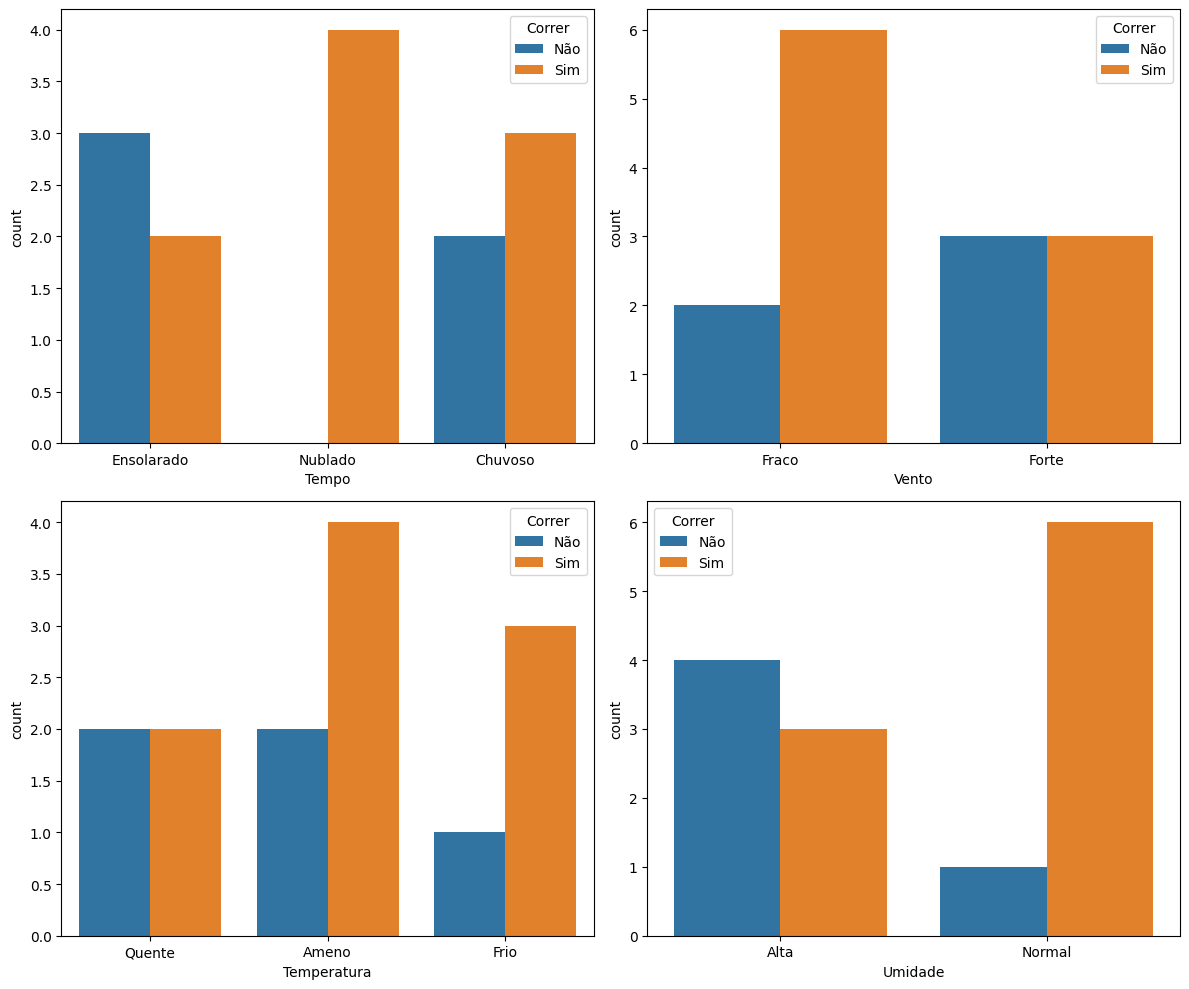

In [2]:
# Para EDA com dados categóricos, usaremos contagens
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Achata o array de eixos para facilitar a indexação (0 a 3)
axes = axes.flatten()

sns.countplot(data=df, x='Tempo', hue='Correr', ax=axes[0])
sns.countplot(data=df, x='Vento', hue='Correr', ax=axes[1])
sns.countplot(data=df, x='Temperatura', hue='Correr', ax=axes[2])
sns.countplot(data=df, x='Umidade', hue='Correr', ax=axes[3])

plt.tight_layout()
plt.show()

### 3. Divisão de Dados e Treinamento
Separando em treino/teste e treinando a Regressão Logística.

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Transformando variáveis categóricas em numéricas (Dummy variables)
df_encoded = pd.get_dummies(df, columns=['Tempo', 'Temperatura', 'Umidade', 'Vento'], drop_first=True)

# Exibindo informações e as primeiras linhas do df_encoded
display(df_encoded.head())

X = df_encoded.drop('Correr', axis=1)
y = df_encoded['Correr']

# Ajustando o split para 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando o modelo de Árvore de Decisão
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# executando o modelo sobre os dados de teste
y_pred = model.predict(X_test)

,Correr,Tempo_Ensolarado,Tempo_Nublado,Temperatura_Frio,Temperatura_Quente,Umidade_Normal,Vento_Fraco
0,Não,True,False,False,True,False,True
1,Não,True,False,False,True,False,False
2,Sim,False,True,False,True,False,True
3,Sim,False,False,False,False,False,True
4,Sim,False,False,True,False,True,True


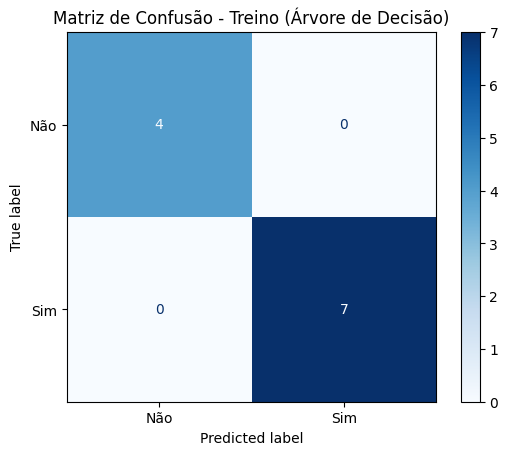

--- Métricas de Treino ---
Acurácia: 1.0000
Recall: 1.0000
Precisão: 1.0000


In [4]:
# Gerando predições para os dados de TREINO
y_train_pred = model.predict(X_train)

# Calculando e exibindo a Matriz de Confusão para o TREINO
cm_train = confusion_matrix(y_train, y_train_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Treino (Árvore de Decisão)')
plt.show()

print("--- Métricas de Treino ---")
print(f'Acurácia: {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Recall: {recall_score(y_train, y_train_pred, pos_label="Sim"):.4f}')
print(f'Precisão: {precision_score(y_train, y_train_pred, pos_label="Sim"):.4f}')

### 4. Visualização da Árvore de Decisão

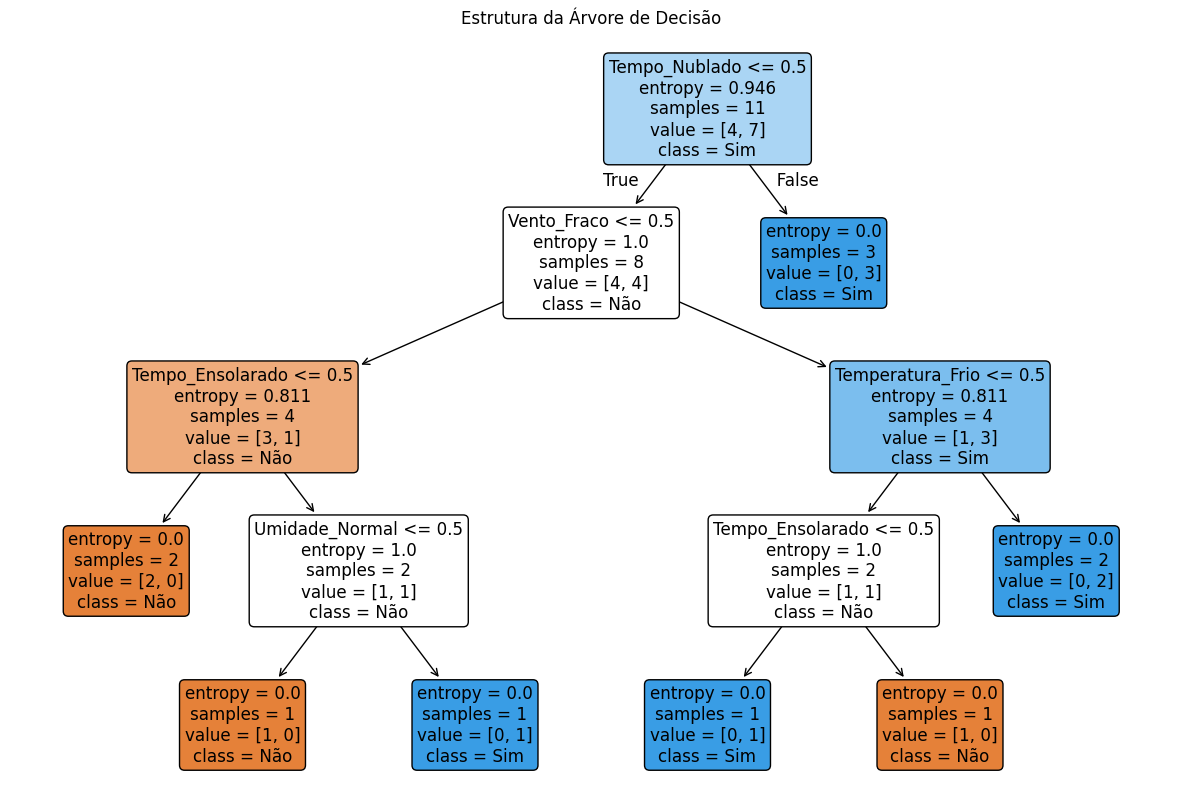

In [5]:
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, rounded=True)
plt.title('Estrutura da Árvore de Decisão')
plt.show()

### 5. Avaliação do Modelo
Exibindo a Matriz de Confusão e cálculos de performance.

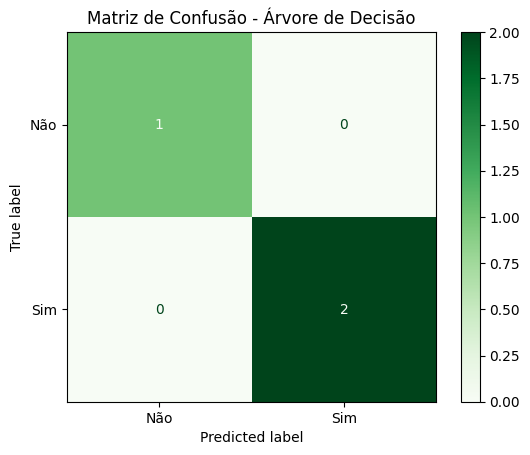

Acurácia: 1.0000
Recall: 1.0000
Precisão: 1.0000


In [6]:
# Calculando e exibindo a Matriz de Confusão e Métricas
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Greens')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

print(f'Acurácia: {accuracy_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred, pos_label="Sim"):.4f}')
print(f'Precisão: {precision_score(y_test, y_pred, pos_label="Sim"):.4f}')